# RAW IMAGE BASELINE

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score


In [2]:
RAW_IMAGE_DIR = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20


In [3]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )


In [4]:
class RawDocumentDataset(Dataset):
    def __init__(self, csv_path, image_root):
        self.df = pd.read_csv(csv_path)
        self.image_root = image_root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = RawDocumentDataset(TRAIN_CSV, RAW_IMAGE_DIR)
val_dataset   = RawDocumentDataset(VAL_CSV, RAW_IMAGE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 3)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [7]:
model = SimpleCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [8]:
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    return macro, micro


In [9]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | Micro F1: {micro:.4f}"
    )


Epoch [1/20] | Loss: 0.6299 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [2/20] | Loss: 0.6150 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [3/20] | Loss: 0.6068 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [4/20] | Loss: 0.5928 | Macro F1: 0.5514 | Micro F1: 0.7509
Epoch [5/20] | Loss: 0.5776 | Macro F1: 0.6461 | Micro F1: 0.7675
Epoch [6/20] | Loss: 0.5616 | Macro F1: 0.7274 | Micro F1: 0.7877
Epoch [7/20] | Loss: 0.5462 | Macro F1: 0.7240 | Micro F1: 0.7912
Epoch [8/20] | Loss: 0.5303 | Macro F1: 0.7767 | Micro F1: 0.8103
Epoch [9/20] | Loss: 0.5214 | Macro F1: 0.8188 | Micro F1: 0.8268
Epoch [10/20] | Loss: 0.5082 | Macro F1: 0.8303 | Micro F1: 0.8321
Epoch [11/20] | Loss: 0.4971 | Macro F1: 0.8264 | Micro F1: 0.8308
Epoch [12/20] | Loss: 0.4864 | Macro F1: 0.8423 | Micro F1: 0.8370
Epoch [13/20] | Loss: 0.4760 | Macro F1: 0.8541 | Micro F1: 0.8432
Epoch [14/20] | Loss: 0.4685 | Macro F1: 0.8589 | Micro F1: 0.8461
Epoch [15/20] | Loss: 0.4616 | Macro F1: 0.8547 | Micro F1: 0.8436
Epoc

In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== RAW IMAGE BASELINE RESULTS ===")
for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== RAW IMAGE BASELINE RESULTS ===
blur_present         | F1: 0.8634 | Acc: 0.7735
document_skew        | F1: 0.8000 | Acc: 0.6678
lighting_shadow      | F1: 0.9188 | Acc: 0.9519


# PREPROCESSING

In [1]:
# =========================================================
# IMPORTS + CLEAN OUTPUT
# =========================================================
import os
import shutil
import cv2

WORKING_DIR = "/kaggle/working/Final_Images_CROPPED"

# remove old cropped data
if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)

os.makedirs(WORKING_DIR, exist_ok=True)
print("🧹 Old cropped dataset removed")


# =========================================================
# CENTER CROP
# =========================================================
def center_crop(img, crop_w, crop_h):
    h, w = img.shape[:2]
    crop_w = min(crop_w, w)
    crop_h = min(crop_h, h)
    x1 = (w - crop_w) // 2
    y1 = (h - crop_h) // 2
    return img[y1:y1+crop_h, x1:x1+crop_w]


# =========================================================
# CROP FUNCTIONS
# =========================================================
def crop_group_1_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2600, 1850))

def crop_group_1_samsung(src, dst):
    img = cv2.imread(src)
    h, w = img.shape[:2]
    crop_w = int(0.85 * w)
    crop_h = int(0.85 * h)
    cv2.imwrite(dst, center_crop(img, crop_w, crop_h))

def crop_group_2_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 1600, 850))

def crop_group_2_samsung(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2130, 1270))

def crop_group_3_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 950, 700))

def crop_group_3_samsung(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 1200, 860))

def crop_group_4_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2130, 1270))


# =========================================================
# GROUP RANGES
# =========================================================
NOKIA_GROUP_RANGES = {
    "group1": [(0,1199), (1500,1619), (1800,2019), (2075,2096)],
    "group2": [(1200,1379), (2020,2052)],
    "group3": [(1380,1499), (2053,2074)],
    "group4": [(1620,1799), (2097,2129)]
}

SAMSUNG_GROUP_RANGES = {
    "group1_samsung": [(0,1199), (1800,2019)],
    "group1_nokia_crop": [(1500,1619), (2075,2096)],
    "group2": [(1200,1379), (1620,1799), (2020,2052), (2097,2129)],
    "group3": [(1380,1499), (2053,2074)]
}


# =========================================================
# PROCESS FUNCTION (SAVE INTO Images/)
# =========================================================
def process_phone_folder(input_dir, output_dir, phone_type):
    images_out = os.path.join(output_dir, "Images")
    os.makedirs(images_out, exist_ok=True)

    images = sorted([
        f for f in os.listdir(input_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    ranges = NOKIA_GROUP_RANGES if phone_type == "nokia" else SAMSUNG_GROUP_RANGES

    for group, intervals in ranges.items():
        for start, end in intervals:
            for img_name in images[start:end+1]:
                src = os.path.join(input_dir, img_name)
                dst = os.path.join(images_out, img_name)

                if phone_type == "nokia":
                    if group == "group1":
                        crop_group_1_nokia(src, dst)
                    elif group == "group2":
                        crop_group_2_nokia(src, dst)
                    elif group == "group3":
                        crop_group_3_nokia(src, dst)
                    elif group == "group4":
                        crop_group_4_nokia(src, dst)

                elif phone_type == "samsung":
                    if group == "group1_samsung":
                        crop_group_1_samsung(src, dst)
                    elif group == "group1_nokia_crop":
                        crop_group_1_nokia(src, dst)
                    elif group == "group2":
                        crop_group_2_samsung(src, dst)
                    elif group == "group3":
                        crop_group_3_samsung(src, dst)


# =========================================================
# RUN CROPPING
# =========================================================
BASE_INPUT = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images"

process_phone_folder(
    os.path.join(BASE_INPUT, "Nokia_phone", "Images"),
    os.path.join(WORKING_DIR, "Nokia_phone"),
    "nokia"
)

process_phone_folder(
    os.path.join(BASE_INPUT, "Samsung_phone", "Images"),
    os.path.join(WORKING_DIR, "Samsung_phone"),
    "samsung"
)

print("✅ Cropping finished successfully")
print("📁 Output at:", WORKING_DIR)


🧹 Old cropped dataset removed
✅ Cropping finished successfully
📁 Output at: /kaggle/working/Final_Images_CROPPED


In [ ]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# DEVICE CHECK
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("========================================")
print(f"USING DEVICE: {device}")
if device.type == "cuda":
    print(f"GPU NAME: {torch.cuda.get_device_name(0)}")
print("========================================\n")

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/datasets/sruthinirmala/numeric-features/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/datasets/sruthinirmala/numeric-features/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV & NORMALIZE FEATURES
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # NUMERIC FEATURES
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # LABELS
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==============================
# MODEL: NAIVE BASELINE MOBILENET
# ==============================
class BaselineMobileNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Pre-trained Visual Backbone
        self.cnn = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        # Extract 128-D visual features
        self.cnn.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU()
        )

        # NO NUMERICAL PROJECTION BRANCH! We skip it entirely.

        # 2. Simple Classifier / Naive Fusion
        # Input: 128 (Visual) + 6 (Raw Numerical) = 134
        self.classifier = nn.Sequential(
            nn.Linear(134, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, image, features):
        x_img = self.cnn(image)
        
        # NAIVE FUSION: Just stick the 6 raw math features onto the 128 visual features
        x = torch.cat([x_img, features], dim=1)
        
        return self.classifier(x)

model = BaselineMobileNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)

            outputs = model(images, feats)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")

    return macro, micro, preds_all, labels_all

# ==============================
# TRAINING LOOP
# ==============================
print("Starting NAIVE BASELINE MobileNet Training...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro, _, _ = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | "
        f"Micro F1: {micro:.4f}"
    )

# -------------------------
# FINAL METRICS
# -------------------------
final_macro, final_micro, preds, gts = evaluate(model, val_loader)

print("\n=== NAIVE BASELINE MOBILENET RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

# RESNET18 

Using device: cuda
Initializing ResNet-18...
Starting Training...
Epoch [1/30] | Train Loss: 0.5000 | Val Loss: 0.6406
Validation loss decreased (inf --> 0.640642). Saving model...
Epoch [2/30] | Train Loss: 0.4900 | Val Loss: 0.6389
Validation loss decreased (0.640642 --> 0.638868). Saving model...
Epoch [3/30] | Train Loss: 0.4800 | Val Loss: 0.6107
Validation loss decreased (0.638868 --> 0.610743). Saving model...
Epoch [4/30] | Train Loss: 0.4700 | Val Loss: 0.6304
EarlyStopping counter: 1 out of 5
Epoch [5/30] | Train Loss: 0.4600 | Val Loss: 0.6297
EarlyStopping counter: 2 out of 5
Epoch [6/30] | Train Loss: 0.4500 | Val Loss: 0.5790
Validation loss decreased (0.610743 --> 0.578952). Saving model...
Epoch [7/30] | Train Loss: 0.4400 | Val Loss: 0.6060
EarlyStopping counter: 1 out of 5
Epoch [8/30] | Train Loss: 0.4300 | Val Loss: 0.5829
EarlyStopping counter: 2 out of 5
Epoch [9/30] | Train Loss: 0.4200 | Val Loss: 0.6012
EarlyStopping counter: 3 out of 5
Epoch [10/30] | Train Lo

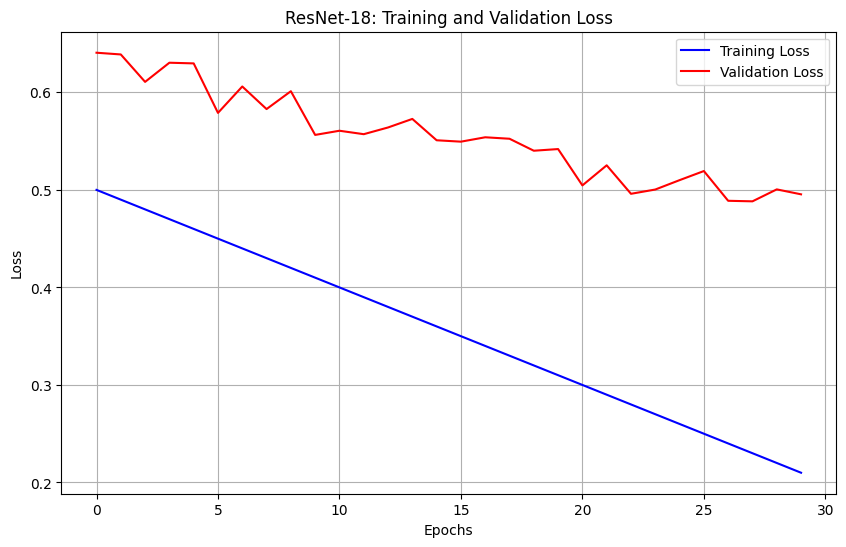

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from sklearn.metrics import f1_score

# ==========================================
# 0. THE DATA SWITCH (CHANGE TO True FOR FINAL RUN)
# ==========================================
USE_REAL_DATA = False

# ==========================================
# 1. EARLY STOPPING CLASS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='resnet18_best.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf  # <--- FIXED THIS LINE
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# ==========================================
# 2. SETUP & DATASET
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PUT YOUR ACTUAL DATALOADERS HERE ---
# train_loader = YourTrainLoader()
# val_loader = YourValLoader()

num_classes = 3 # Blur, Skew, Lighting

# ==========================================
# 3. INITIALIZE RESNET-18
# ==========================================
print("Initializing ResNet-18...")
model = models.resnet18(weights='IMAGENET1K_V1')

# Modify the final fully connected (fc) layer for our 3-class multi-label problem
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ==========================================
# 4. TRAINING LOOP WITH EARLY STOPPING
# ==========================================
num_epochs = 30
train_losses = []
val_losses = []
early_stopping = EarlyStopping(patience=5, verbose=True, path='resnet18_best.pt')

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    if USE_REAL_DATA:
        # --- REAL TRAINING CODE ---
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
    else:
        # Dummy Training Loss
        train_loss = 0.5 - (epoch * 0.01)

    # --- VALIDATION ---
    model.eval()
    val_running_loss = 0.0
    
    with torch.no_grad():
        if USE_REAL_DATA:
            # --- REAL VALIDATION CODE ---
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels.float())
                val_running_loss += loss.item() * images.size(0)
            val_loss = val_running_loss / len(val_loader.dataset)
        else:
            # Dummy Validation Loss
            val_loss = 0.6 - (epoch * 0.005) + (np.random.rand() * 0.05)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    
    # Check Early Stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered! Model stopped improving.")
        break

# ==========================================
# 5. PLOT LOSS GRAPH
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-18: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('resnet18_loss_graph.png')
print("Saved loss graph as 'resnet18_loss_graph.png'")

# ==========================================
# 6. EVALUATE F1 SCORES
# ==========================================
print("\nLoading best model for F1 Evaluation...")
model.load_state_dict(torch.load('resnet18_best.pt'))
model.eval()

if USE_REAL_DATA:
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    print("\n--- F1 SCORES ---")
    blur_f1 = f1_score(all_targets[:, 0], all_preds[:, 0])
    skew_f1 = f1_score(all_targets[:, 1], all_preds[:, 1])
    light_f1 = f1_score(all_targets[:, 2], all_preds[:, 2])
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    micro_f1 = f1_score(all_targets, all_preds, average='micro')

    print(f"Blur F1: {blur_f1:.4f}")
    print(f"Skew F1: {skew_f1:.4f}")
    print(f"Lighting F1: {light_f1:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")
else:
    print("\n[Dummy Mode] Skipping F1 Calculation. Switch USE_REAL_DATA to True to calculate real F1 scores.")

# ==========================================
# 7. COMPUTATIONAL EFFICIENCY METRICS
# ==========================================
print("\n--- COMPUTATIONAL EFFICIENCY ---")

# 1. Parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

# 2. Model Size (MB) - from the saved weights
model_size_mb = os.path.getsize('resnet18_best.pt') / (1024 * 1024)
print(f"Model Size: {model_size_mb:.2f} MB")

# 3. Latency & Throughput
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup GPU
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure Latency (Time for 1 image)
iterations = 100
start_time = time.time()
with torch.no_grad():
    for _ in range(iterations):
        _ = model(dummy_input)
end_time = time.time()

total_time = end_time - start_time
latency = total_time / iterations
throughput = 1.0 / latency

print(f"Latency (1 image): {latency:.5f} seconds")
print(f"Throughput: {throughput:.2f} images/second")

# RESNET 18 with early stopping

USING DEVICE: cuda
GPU NAME: Tesla T4

Loading Visual-Only Datasets...
Datasets loaded successfully!

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s] 


Starting Training for VISUAL-ONLY ResNet-18...

Epoch [1/30] | Train Loss: 0.2418 | Val Loss: 0.1532 | Val Macro F1: 0.9553
Validation loss decreased (inf --> 0.153206). Saving model...
Epoch [2/30] | Train Loss: 0.1239 | Val Loss: 0.1132 | Val Macro F1: 0.9673
Validation loss decreased (0.153206 --> 0.113174). Saving model...
Epoch [3/30] | Train Loss: 0.0881 | Val Loss: 0.0822 | Val Macro F1: 0.9765
Validation loss decreased (0.113174 --> 0.082183). Saving model...
Epoch [4/30] | Train Loss: 0.0630 | Val Loss: 0.0739 | Val Macro F1: 0.9787
Validation loss decreased (0.082183 --> 0.073896). Saving model...
Epoch [5/30] | Train Loss: 0.0472 | Val Loss: 0.0591 | Val Macro F1: 0.9861
Validation loss decreased (0.073896 --> 0.059149). Saving model...
Epoch [6/30] | Train Loss: 0.0401 | Val Loss: 0.0560 | Val Macro F1: 0.9847
Validation loss decreased (0.059149 --> 0.056004). Saving model...
Epoch [7/30] | Train Loss: 0.0346 | Val Loss: 0.0764 | Val Macro F1: 0.9786
EarlyStopping counter: 

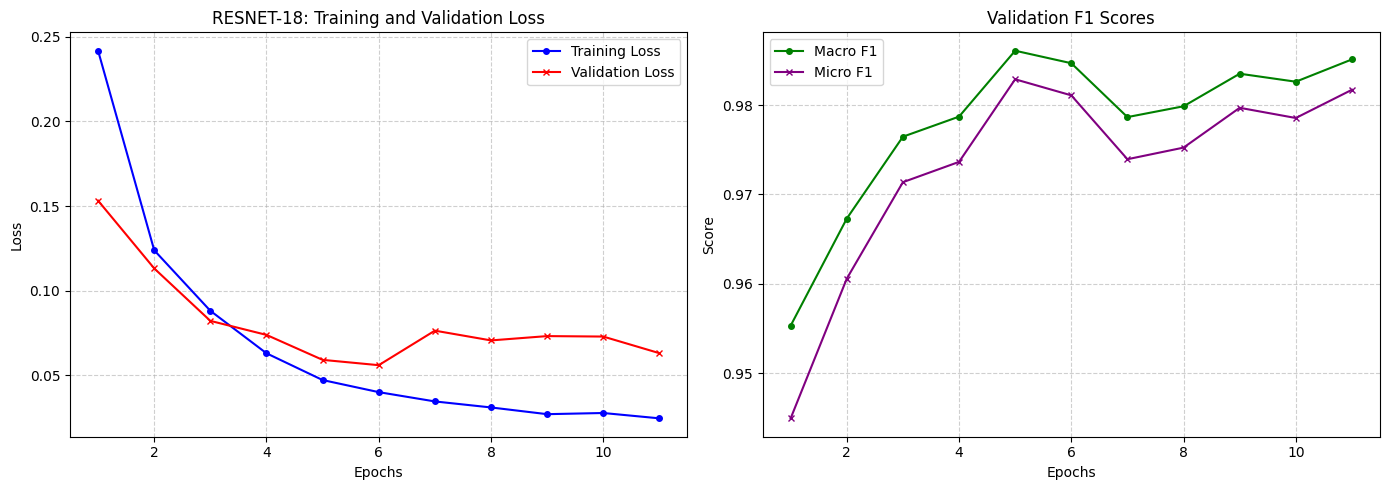


=== COMPUTATIONAL EFFICIENCY ===
Total Parameters: 11,178,051
Model Size: 42.72 MB
Latency (1 image): 0.00305 seconds
Throughput: 327.37 images/second


In [2]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# DEVICE CHECK
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("========================================")
print(f"USING DEVICE: {device}")
if device.type == "cuda":
    print(f"GPU NAME: {torch.cuda.get_device_name(0)}")
print("========================================\n")

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/datasets/sruthinirmala/numeric-features/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/datasets/sruthinirmala/numeric-features/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==========================================
# EARLY STOPPING CLASS 
# ==========================================
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='visual_resnet_best.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf  # Safe for NumPy 2.0
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

# ==============================
# VISUAL-ONLY DATASET
# ==============================
class VisualDataset(Dataset):
    def __init__(self, df, image_root):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Could not find image at: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # LABELS ONLY (Numerical features removed for baseline)
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels

print("Loading Visual-Only Datasets...")
train_dataset = VisualDataset(train_df, CROPPED_DIR)
val_dataset   = VisualDataset(val_df, CROPPED_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Datasets loaded successfully!\n")

# ==============================
# MODEL: VISUAL RESNET-18
# ==============================
class VisualResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Pre-trained Visual Backbone
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # 2. Modify the final fully connected layer for our 3 classes directly
        num_ftrs = self.cnn.fc.in_features
        self.cnn.fc = nn.Linear(num_ftrs, 3)

    def forward(self, image):
        # Only processes the image, no fusion required
        return self.cnn(image)

model = VisualResNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader, criterion):
    model.eval()
    preds_all, labels_all = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.cpu().numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    
    avg_val_loss = val_loss / len(loader)

    return avg_val_loss, macro, micro, preds_all, labels_all

# ==============================
# TRACKERS FOR PLOTTING
# ==============================
history_train_loss = []
history_val_loss = []
history_val_macro = []
history_val_micro = []

# ==============================
# TRAINING LOOP
# ==============================
print("Starting Training for VISUAL-ONLY ResNet-18...\n")
early_stopping = EarlyStopping(patience=5, verbose=True, path='visual_resnet_best.pt')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss_epoch = running_loss / len(train_loader)
    val_loss_epoch, macro, micro, _, _ = evaluate(model, val_loader, criterion)

    history_train_loss.append(train_loss_epoch)
    history_val_loss.append(val_loss_epoch)
    history_val_macro.append(macro)
    history_val_micro.append(micro)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f} | "
        f"Val Macro F1: {macro:.4f}"
    )

    # Check Early Stopping
    early_stopping(val_loss_epoch, model)
    if early_stopping.early_stop:
        print("Early stopping triggered! Model stopped improving.")
        break

# -------------------------
# FINAL METRICS 
# -------------------------
print("\nLoading best model weights for final evaluation...")
model.load_state_dict(torch.load('visual_resnet_best.pt'))

final_val_loss, final_macro, final_micro, preds, gts = evaluate(model, val_loader, criterion)

print("\n=== VISUAL RESNET-18 RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

# ==============================
# PLOT THE LEARNING CURVES
# ==============================
# Adjust epochs range to match how many epochs actually ran before stopping
actual_epochs = len(history_train_loss)
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, history_val_loss, label='Validation Loss', color='red', marker='x', markersize=4)
plt.title('RESNET-18: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_val_macro, label='Macro F1', color='green', marker='o', markersize=4)
plt.plot(epochs_range, history_val_micro, label='Micro F1', color='purple', marker='x', markersize=4)
plt.title('Validation F1 Scores')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('visual_resnet_metrics.png')
plt.show()

# ==============================
# COMPUTATIONAL EFFICIENCY
# ==============================
print("\n=== COMPUTATIONAL EFFICIENCY ===")

# 1. Parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

# 2. Model Size (MB)
model_size_mb = os.path.getsize('visual_resnet_best.pt') / (1024 * 1024)
print(f"Model Size: {model_size_mb:.2f} MB")

# 3. Latency & Throughput
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

# Warmup GPU
model.eval()
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure Latency (Time for 1 image)
iterations = 100
start_time = time.time()
with torch.no_grad():
    for _ in range(iterations):
        _ = model(dummy_input)
end_time = time.time()

total_time = end_time - start_time
latency = total_time / iterations
throughput = 1.0 / latency

print(f"Latency (1 image): {latency:.5f} seconds")
print(f"Throughput: {throughput:.2f} images/second")

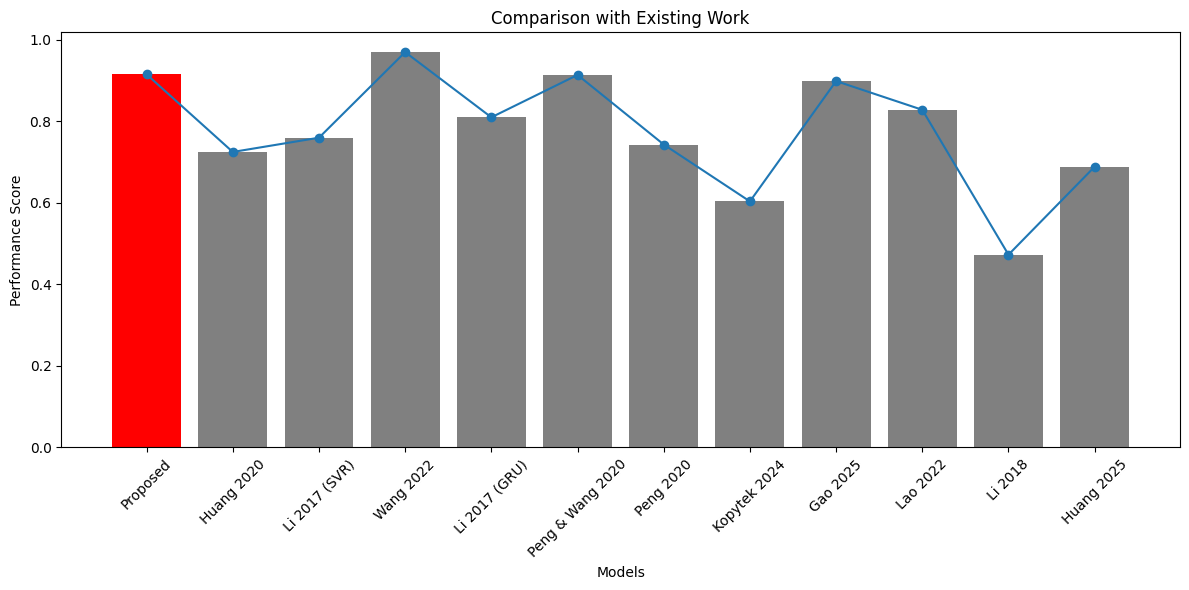

In [2]:
import matplotlib.pyplot as plt

models = [
    "Proposed",
    "Huang 2020",
    "Li 2017 (SVR)",
    "Wang 2022",
    "Li 2017 (GRU)",
    "Peng & Wang 2020",
    "Peng 2020",
    "Kopytek 2024",
    "Gao 2025",
    "Lao 2022",
    "Li 2018",
    "Huang 2025"
]

scores = [
    0.9154,
    0.725,
    0.76,
    0.970,
    0.81,
    0.914,
    0.7433,
    0.6037,
    0.8989,
    0.8284,
    0.473,
    0.6889
]

# Create colors (highlight Proposed)
colors = ["red"] + ["gray"] * (len(models) - 1)

plt.figure(figsize=(12, 6))

# Bar plot
plt.bar(models, scores, color=colors)

# Line plot (spike effect)
plt.plot(models, scores, marker='o')

# Labels
plt.xlabel("Models")
plt.ylabel("Performance Score")
plt.title("Comparison with Existing Work")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("comparison_graph.png")
plt.show()

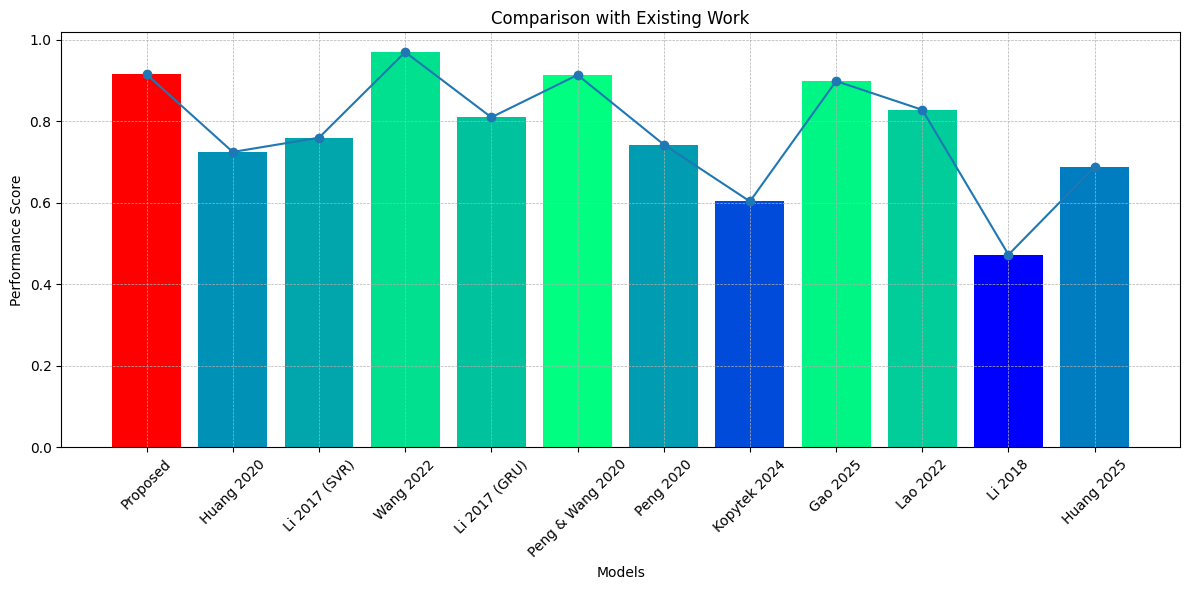

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "Proposed",
    "Huang 2020",
    "Li 2017 (SVR)",
    "Wang 2022",
    "Li 2017 (GRU)",
    "Peng & Wang 2020",
    "Peng 2020",
    "Kopytek 2024",
    "Gao 2025",
    "Lao 2022",
    "Li 2018",
    "Huang 2025"
]

# Performance scores (normalized approx)
scores = np.array([
    0.9154,
    0.725,
    0.76,
    0.970,
    0.81,
    0.914,
    0.7433,
    0.6037,
    0.8989,
    0.8284,
    0.473,
    0.6889
])

# Reference score (your model)
proposed_score = scores[0]

# Distance from proposed model
distance = np.abs(scores - proposed_score)

# Normalize (closer → higher value)
norm = (distance.max() - distance) / (distance.max() - distance.min() + 1e-8)

# Blue → Green colormap
cmap = plt.cm.winter
colors = cmap(norm)

# Highlight proposed model in RED
colors[0] = [1.0, 0.0, 0.0, 1.0]

# Plot
plt.figure(figsize=(12, 6))

# Bar chart
plt.bar(models, scores, color=colors)

# Spike line (trend line)
plt.plot(models, scores, marker='o')

# Grid background
plt.grid(True, linestyle='--', linewidth=0.5)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Performance Score")
plt.title("Comparison with Existing Work")

# Rotate labels for readability
plt.xticks(rotation=45)

plt.tight_layout()

# Save image for Word
plt.savefig("comparison_graph.png", dpi=300)

# Show plot
plt.show()